In [91]:
import pandas as pd
# import pylab as plt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
pd.options.mode.chained_assignment = None  # default='warn'

sns.set(font_scale=1.2,style="whitegrid")
%matplotlib inline

import tjn_tools
from tjn_tools.data_processing import *
import tjn_internal
from tjn_internal.style_guide import *

# from style_guide import *
# #Import some data_processing tools to convert names to ISO3 
# from data_processing import *


#Avoid overlapping text|
from adjustText import adjust_text
from datetime import datetime


import statsmodels.formula.api as smf
from itertools import permutations, product
import pickle

pd.set_option('display.max_columns', 100)

In [122]:
path_files = "../data/raw/"
path_files_final = "../data/final/"
path_files_temp = "../data/processing/"

year_cbcr = 2017 #CBCR year to study

# now = datetime.now().year
last_year_mean = year_cbcr-6 #from now until 10 years ago

## Section 1
#Input
cbcr_file = f"{path_files}CBCR_TABLEI_17112022170811646.csv"

orbis_file = f"{path_files}orbis.xlsx" #TODO Use up-to-date data #TODO ask Javier how and where to retrieve it

#Output
etr_output = f"{path_files_final}{year_cbcr}_cbcr_etr_rates.xlsx"
cbcr_output = f"{path_files_final}{year_cbcr}_cbcr_cleaned_dividends.xlsx"


## Section 2
#Input
country_level = f"{tjn_internal.paths.final_data}/20210810_country-level-data.csv" # unilateral cross #TODO Use 2022 data
country_year_level = f"{tjn_internal.paths.final_data}/20210810_country-year-level-data.csv" # unilateral panel #TODO Use 2022 data
bilateral_level = f"{tjn_internal.paths.final_data}/20210810_bilateral-year-level-data.csv" # bilateral cross #TODO Use 2022 data
grav_file = f"{tjn_internal.paths.source_data}/022 CEPII/other/Gravity_V202102.dta" #TODO Use 2022 data
link_file = f"{tjn_internal.paths.source_data}/016 Papers/garcia-stausholm2020/combined_data_imputed copy.tsv" #TODO Use 2022 data

#Output
df_pairs_output = f"{path_files_final}{year_cbcr}_df_pairs.tsv"
df_fin_output = f"{path_files_final}{year_cbcr}_df_fin.tsv"
d_groups2countries_output = f"{path_files_final}{year_cbcr}_d_groups2countries.dump"
iso3_to_wages_output = f"{path_files_final}{year_cbcr}_iso3_to_wages.dump"
iso3_to_cit_output = f"{path_files_final}{year_cbcr}_iso3_to_cit.dump"
iso3_to_gdp_output = f"{path_files_final}{year_cbcr}_iso3_to_gdp.dump"
info_expenditures_output = f"{path_files_final}{year_cbcr}_info_expenditures.csv"



In [93]:
#OFCs
ofcs = {'MLT', 'BRB', 'BMU', 'CUW', 'CYP', 'HKG', 'PRI', 'SGP', 'IRL', 'MUS', 'VGB', 'CYM', 
              'LUX', 'JEY', 'IMN', 'NLD', 'GIB', 'CHE', 'BHS', 'GGY', 'MAC', 'HUN', 'ARE'}
groups = {"ASIAT","EUROP","AMER","AFRIC",'OTE','OAM',"OAF","OAS"} 
#Other america and other europe usualyl contain many tax havens. When split only by continent, remove across all conutries


In [94]:
#CIT rates
cit_file = f"{path_files}corporate tax rates.csv" #tax rate #TODO ask Javier how and where to retrieve it
iso3_to_cit  = pd.read_csv(cit_file)
iso3_to_cit = iso3_to_cit.loc[iso3_to_cit["year"]==year_cbcr].groupby("country_iso3")["nctr_final"].mean()

iso3_to_cit["MLT"] *= 1/7 #(6/7th rule)
iso3_to_cit["GIB"] = 0 #only resident income
iso3_to_cit["MCO"] = 0
iso3_to_cit["AND"] = 0
iso3_to_cit["CAF"] = 0.3
iso3_to_cit["HTI"] = 0.3
iso3_to_cit["YEM"] = 0.2
iso3_to_cit["NCL"] = 0 #Only NCL income is taxable
iso3_to_cit["PRK"] = 0.325
iso3_to_cit["COD"] = 0.28
iso3_to_cit["TLS"] = 0.10
iso3_to_cit["ROU"] = iso3_to_cit["ROM"]
iso3_to_cit["USA"] = 0.27 # State tax included

pickle.dump(iso3_to_cit,open(iso3_to_cit_output,"wb+"))

In [95]:
for i in set(iso3_to_cit[np.isnan(iso3_to_cit)].index):
    print(i,iso3_to_name(i))

FLK Falkland Islands
KIR Kiribati
FSM Micronesia
ANT Netherlands Antilles
MTQ Martinique
SJM Svalbard and Jan Mayen Islands
GRL Greenland
SHN Saint Helena
SGS South Georgia and the South Sandwich Islands
NIU Niue
NRU Nauru
MYT Mayotte
VIR US Virgin Islands
CXR Christmas Island
IOT British Indian Ocean Territory
SSD South Sudan
MSR Montserrat
WLF Wallis and Futuna Islands
BLZ Belize
SMR San Marino
STP Sao Tome and Principe
FRO Faroe Islands
GLP Guadeloupe
NFK Norfolk Island
BVT Bouvet Island
VAT Vatican
ESH Western Sahara
COK Cook Islands
GUF French Guiana
HMD Heard Island and McDonald Islands
ERI Eritrea
GUY Guyana
REU Reunion
SOM Somalia
TKL Tokelau
IRN Iran
PCN Pitcairn
TON Tonga
VGB British Virgin Islands
TMP Timor-Leste
MNP Northern Mariana Islands
ATA Antarctica
CCK Cocos Islands
LBR Liberia
PYF French Polynesia
CUB Cuba
TUV Tuvalu
MHL Marshall Islands
COM Comoros


# 1. Clean CBCR data and calculate ETR
- Input file: CBCR (https://stats.oecd.org/Index.aspx?DataSetCode=CBCR_TABLEI)
- Orbis with number of expected companies
    - Columns needed:
        - Country ISO code
        - Operating revenue
        - Number of employees
        - GUO code
    - Search strategy:
        - Status: Active companies, Unknown situation
        - Operating revenue (Turnover), using estimates (m USD): min=850, Last available year, exclusion of companies with no recent financial data and Public authorities/States/Governments
        - Ultimate Owners: Global; Def. of the UO: min. path of 50.01%, known or unknown shareholder
        - Shareholders with foreign subsidiaries: located anywhere (excluding unknown countries) not ultimately owned but at least 51% owned; May have other shareholder in the foreign country; Def. of the UO: min. path of 50.01%, known or unknown shareholder
        - NACE Rev. 2, core code (4 digits): Different from 65


In [96]:
fin_needed = ['Unrelated Party Revenues','Profit (Loss) before Income Tax', 'Adjusted Profit (Loss) before Income Tax',
       'Income Tax Paid (on Cash Basis)','Income Tax Accrued - Current Year','Number of Employees',
       'Tangible Assets other than Cash and Cash Equivalents','Number of CbCRs','Number of CbCR Sub Groups','Number of Entities']

In [97]:
## Functions to calculate ETRs
def calculate_etr(df):
    d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
    d["etr"] = d["Income Tax Paid (on Cash Basis)"]/d["Profit (Loss) before Income Tax"]
    return d["etr"]

def main_etrs(year,file,g="Sub-Groups with positive profits"):
    if isinstance(file,str):
        df = pd.read_csv(file,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
        df = df.loc[df["Grouping"]==g]
        df = df.loc[df["Variable"].isin(fin_needed)]
        df = df.loc[df["Year"]==year]
        df = pd.pivot_table(df,index=["COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
    else:
        df = file
    df = df.dropna(subset=["Income Tax Paid (on Cash Basis)"])

    df_for = df.loc[df["COU"] != df["JUR"]]
    df_dom = df.loc[df["COU"] == df["JUR"]]
    df_tot = df

    df_etr = pd.concat([calculate_etr(df_for),
                       calculate_etr(df_dom),
                       calculate_etr(df_tot)],
                      axis=1)
    df_etr.columns = ["ETR_foreign","ETR_domestic","ETR_total"]
    return df_etr
#     df_etr.to_excel(etr_output)

#     df_etr.head()

## 1.1 CBCR vs Orbis: Compare coverage

US911646860        1
MY731568-V         1
CA40870NC          1
JP9010401054420    1
SE5567658769       1
Name: GUO - BvD ID number, dtype: int64
US911646860        1
MY731568-V         1
CA40870NC          1
JP9010401054420    1
SE5567658769       1
Name: GUO - BvD ID number, dtype: int64
 not matched to any file
II not matched to any file


54.0

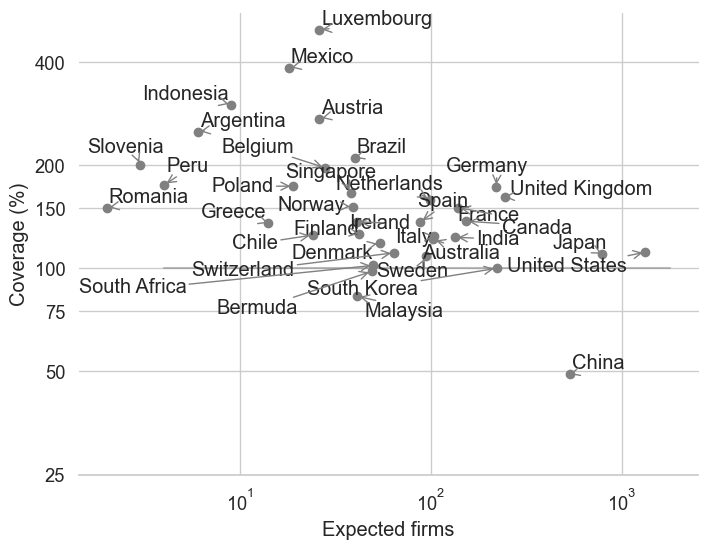

In [98]:
#CBCR number of companies
total_cov = pd.read_csv(cbcr_file,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
total_cov = total_cov.loc[total_cov["Year"]==year_cbcr]
total_cov = total_cov.loc[total_cov["Grouping"]=="All Sub-Groups"]
total_cov = total_cov.loc[total_cov["Variable"]=="Number of CbCRs"]
total_cov = total_cov.loc[total_cov["JUR"]==total_cov["COU"]]
total_cov = total_cov.groupby(["COU"]).max()["Value"]

## Compare quality with Orbis (companies with >750M of turnover, including estimates, and keeping companies with foreign subsidiaries)
cs = pd.read_excel(orbis_file,na_values=["n.a."],keep_default_na=False)
cs = cs.dropna(subset=["GUO - BvD ID number"])
cs = cs.loc[(cs["Country ISO code"]==cs["GUO - BvD ID number"].str[:2])|(cs["GUO - BvD ID number"].str[:2]=="WW")]
cs["max_turnover"] = cs.groupby(["GUO - BvD ID number"])["Operating revenue (Turnover)\nth USD Last avail. yr"].transform(max)
cs = cs.loc[cs["Operating revenue (Turnover)\nth USD Last avail. yr"]==cs["max_turnover"]]
print(cs["GUO - BvD ID number"].value_counts().head()) #makek sure no repeated, in case of equal turnovers

cs = cs.drop_duplicates(subset=["GUO - BvD ID number"])
cs.loc[(cs["Country ISO code"]!=cs["GUO - BvD ID number"].str[:2])&(cs["GUO - BvD ID number"].str[:2]!="WW"),"Country ISO code"] = cs.loc[(cs["Country ISO code"]!=cs["GUO - BvD ID number"].str[:2])&(cs["GUO - BvD ID number"].str[:2]!="WW"),"GUO - BvD ID number"].str[:2]
print(cs["GUO - BvD ID number"].value_counts().head()) #makek sure no repeated, in case of equal turnovers

cs = cs.groupby("Country ISO code").agg({"GUO - BvD ID number": len,"Operating revenue (Turnover)\nth USD Last avail. yr":np.sum,"Number of employees\nLast avail. yr":np.sum}).reset_index()
cs.columns = ["country","Number companies expected","Turnover expected","Emp expected"]
cs["Turnover expected"] *= 1000
cs["country"] = cs["country"].map(get_iso3)
cs = cs.dropna(subset=["country"])

#This array is used in 99.cluster_photoshop
potential_countries = cs.loc[cs["Number companies expected"]>=3,"country"].values

cs = pd.concat([cs.set_index("country"),total_cov],axis=1)
cs["Coverage"] = np.log2(cs["Value"]/cs["Number companies expected"])


cs_plot = cs.dropna()
plt.figure(figsize=(8,6))
plt.plot(cs_plot["Number companies expected"],cs_plot["Coverage"],"o",color="gray")

texts = []
for c,x,y in zip(cs_plot.index,cs_plot["Number companies expected"],cs_plot["Coverage"]):
    texts.append(plt.text(x,y,iso3_to_name(c)))


plt.plot([4,1800],[0,0],alpha=0.5,color="gray")             
plt.xscale("log")

adjust_text(texts,cs_plot["Number companies expected"].values, cs_plot["Coverage"].values, 
            arrowprops=dict(arrowstyle='->', color='gray'))
bins = np.array([0.25,0.5,0.75,1,1.5,2,4])
coverage = np.log2(bins)
plt.yticks(coverage,np.array(100*bins,dtype=int))
plt.xlabel("Expected firms")
plt.ylabel("Coverage (%)")
sns.despine(bottom=False,left=True)


expected_companies = cs["Number companies expected"]
expected_companies = expected_companies.to_dict()
expected_companies["DNK"]

In [99]:
cs_plot["Ratio"] = cs_plot["Number companies expected"]/cs_plot["Value"]
x = cs_plot[["Number companies expected","Value","Ratio"]].sort_values(by="Ratio", ascending=False)
x.index = x.index.map(iso3_to_name)
x["Number companies expected"] = x["Number companies expected"].astype(int)
x["Value"] = x["Value"].astype(int)
x["Ratio"] = x["Ratio"].round(2)
x

,Number companies expected,Value,Ratio
China,538,264,2.04
Malaysia,41,34,1.21
Bermuda,49,48,1.02
South Korea,221,221,1.00
South Africa,50,51,0.98
Sweden,94,102,0.92
Japan,785,866,0.91
Switzerland,64,71,0.90
United States,1334,1487,0.90
Denmark,54,64,0.84


In [100]:
potential_countries

array(['ARE', 'ARG', 'AUT', 'AUS', 'BEL', 'BHR', 'BMU', 'BRA', 'CAN',
       'CHE', 'CHL', 'CHN', 'COL', 'CYP', 'CZE', 'DEU', 'DNK', 'EGY',
       'ESP', 'FIN', 'FRA', 'GBR', 'GRC', 'HKG', 'HUN', 'IDN', 'IRL',
       'ISR', 'IND', 'IRN', 'ITA', 'JPN', 'KOR', 'KWT', 'CYM', 'KAZ',
       'LUX', 'MAR', 'MEX', 'MYS', 'NGA', 'NLD', 'NOR', 'NZL', 'PAN',
       'PER', 'PHL', 'POL', 'PRT', 'QAT', 'RUS', 'SAU', 'SWE', 'SGP',
       'SVN', 'THA', 'TUR', 'TWN', 'USA', 'VGB', 'VNM', 'ZAF'],
      dtype=object)

In [101]:
df = pd.read_csv(cbcr_file,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
# df = df.loc[df["Grouping"]=="Sub-Groups with positive profits"]
df = df.loc[df["Grouping"]=="All Sub-Groups"]
df = df.loc[df["Year"]==year_cbcr]
df = df.loc[df["Variable"].isin(fin_needed)]
df = pd.pivot_table(df,index=["COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
if "Adjusted Profit (Loss) before Income Tax" in list(df.columns):
    df.dropna(subset=["Adjusted Profit (Loss) before Income Tax"])[["JUR","Profit (Loss) before Income Tax", "Adjusted Profit (Loss) before Income Tax"]].set_index("JUR")/1E9

In [102]:
df = pd.read_csv(cbcr_file)
df = df.loc[df["Year"]==2017]
df1 = df.loc[df["Grouping"]=="Sub-Groups with positive profits"]
a = df1[["COU","Partner Jurisdiction"]].drop_duplicates().reset_index(drop=True)["COU"].value_counts()

df1 = df.loc[df["Grouping"]=="All Sub-Groups"]
b = df1[["COU","Partner Jurisdiction"]].drop_duplicates().reset_index(drop=True)["COU"].value_counts()

pd.concat([b,a],axis=1).transpose().fillna(0).astype(int)

,JPN,IND,DEU,USA,ZAF,CHN,CHE,ESP,DNK,ITA,BMU,MEX,LUX,FRA,AUS,IDN,BRA,MYS,SGP,BEL,PER,ARG,CAN,LVA,CHL,IMN,SVN,ROU,GBR,SWE,GRC,NOR,AUT,POL,FIN,KOR,IRL,NLD
COU,200,164,161,147,139,125,122,120,115,110,101,97,92,90,82,43,43,36,29,21,20,19,16,14,10,7,7,7,7,7,6,6,6,5,2,2,2,2
COU,185,135,158,99,115,92,121,80,115,81,69,61,91,40,57,31,31,27,38,21,12,15,16,0,10,7,6,7,6,7,6,6,5,0,2,2,2,2


In [103]:
#Make sure the cleaning in 2016  (multiplying everything by 2 in china) was mostly okay
df = pd.read_csv(cbcr_file,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
df = df.loc[df["Grouping"]=="Sub-Groups with positive profits"]
# df = df.loc[df["Grouping"]=="All Sub-Groups"]
df = df.loc[df["Variable"].isin(fin_needed+['Number of CbCRs'])]
df = pd.pivot_table(df,index=["Year","COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
# df.dropna(subset=["Adjusted Profit (Loss) before Income Tax"])[["JUR","Profit (Loss) before Income Tax", "Adjusted Profit (Loss) before Income Tax"]].set_index("JUR")/1E9
df.loc[(df["JUR"]=="COD")]


Variable,Year,COU,JUR,Partner Jurisdiction,Adjusted Profit (Loss) before Income Tax,Income Tax Accrued - Current Year,Income Tax Paid (on Cash Basis),Number of CbCR Sub Groups,Number of CbCRs,Number of Employees,Number of Entities,Profit (Loss) before Income Tax,Tangible Assets other than Cash and Cash Equivalents,Unrelated Party Revenues
853,2016,ZAF,COD,Democratic Republic of the Congo,NaN,4.379733e+06,5.813607e+06,4.0,4.0,177.0,7.0,55954533.0,4.693023e+07,1.019855e+08
1287,2017,CHN,COD,Democratic Republic of the Congo,NaN,1.869742e+07,1.155755e+07,7.0,7.0,4057.0,19.0,68889224.0,6.037538e+08,1.684346e+08
2043,2017,JPN,COD,Democratic Republic of the Congo,NaN,1.052030e+06,5.057420e+05,1.0,1.0,234.0,2.0,3795278.0,2.943714e+07,6.015086e+07
2573,2017,ZAF,COD,Democratic Republic of the Congo,NaN,3.601608e+06,1.790003e+06,2.0,2.0,149.0,2.0,10299477.0,3.474348e+07,7.490633e+07
2909,2018,CHE,COD,Democratic Republic of the Congo,NaN,NaN,NaN,2.0,2.0,NaN,7.0,NaN,NaN,NaN
3205,2018,DEU,COD,Democratic Republic of the Congo,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
4401,2018,ROU,COD,Democratic Republic of the Congo,NaN,6.314050e+05,5.354520e+05,1.0,1.0,66.0,1.0,6330187.0,6.029443e+07,4.829127e+07


## 1.2 Read and clean CBCR
- Data limitations: https://www.oecd.org/tax/tax-policy/anonymised-and-aggregated-cbcr-statistics-disclaimer.pdf
- Report: https://www.oecd.org/tax/tax-policy/corporate-tax-statistics-database.htm


- Data on the United States --> Cleaned in the paper with Zucman
    - US domestic: 55%
    - US foreign: 7% (https://gabriel-zucman.eu/files/GBJZ2021.pdf)

- Other countries: correct using notes when possible:
    - Ireland: https://www.oecd.org/tax/tax-policy/ireland-cbcr-country-specific-analysis.pdf
        --> No issues found
    - Italy: https://www.oecd.org/tax/tax-policy/italy-cbcr-country-specific-analysis.pdf
        -->  The average value of the share of dividends is instead equal to 38.2%, thus implying that dividends are concentrated in few firms.  
    - Netherlands: https://www.oecd.org/tax/tax-policy/united-kingdom-cbcr-country-specific-analysis.pdf
        --> 5794 out of 36802 = 15.74%
    - United Kingdom: https://www.oecd.org/tax/tax-policy/united-kingdom-cbcr-country-specific-analysis.pdf
        --> UK reported profit.: The total value of dividends extracted for groups we believe had included intragroup dividends received was approximately £55 billion. (78.169865 out of 152.918884 = 51.1%) 	)
    - Sweden: https://www.oecd.org/tax/tax-policy/sweden-cbcr-country-specific-analysis.pdf
        --> Dividends share 51.95%


Correct for dividends, but not for participation results (de-mergers, takeovers and disposal typically involve tax avoidance strategies in tax havens.) 


Cleaning strategy based on the analysis below:
- Profit and coordination centers:
    - Domestic: Analysis done for those countries (except Belgium and LUX)
        - Belgium: 50% (same as uk/swe)
        - LUX: Nothing (tax rates are usually around there)
    - Foreign : 
        -Remove 10% (a bit more than what we find in the US for that year (9% = 42 double counting/454 tax havens))
- USA:
    - Domestic: 
        - Remove 35%
    - Foreign: 
        - No correction


- Other countries:
    - Domestic:
        - If domestic etr << foreign etr (10 points): Correct as in ita (35%)
    - Foreign: 
        - No correction

- Groups:
    - Domestic:
        - N/A
    - Foreign:
        - Remove 5% (10% from tax havens, with 50% of profits in tax havens)


/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_9820/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_9820/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_9820/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will defaul

Text(0, 0.5, 'ETR (Foreign MNCs)')

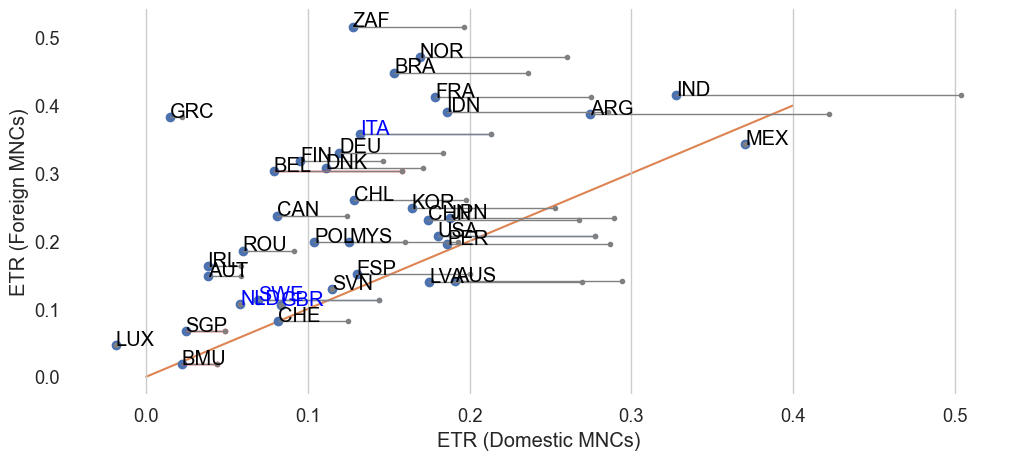

In [104]:
#Check out cleaning. USe all groups to get a most comparable picture
df_etrs = main_etrs(year=year_cbcr,file=cbcr_file,g="All Sub-Groups")
df_etrs["cit"] = df_etrs.index.map(iso3_to_cit)
df_etrs

plt.figure(figsize=(12,5))
for i,row in df_etrs.iterrows():
    if row["ETR_domestic"]>-0.2:
        if i in ["NLD","GBR","ITA","SWE"]:
            color = "blue"
        else:
            color = "black"
        plt.annotate(i,(row["ETR_domestic"],row["ETR_foreign"]),color=color)
plt.plot(df_etrs["ETR_domestic"],df_etrs["ETR_foreign"],"o")


def plot_c(cs,color="tomato"):
    c,fraction = cs
    plt.plot(df_etrs.loc[c,"ETR_domestic"]*(1+fraction/(1-fraction)),df_etrs.loc[c,"ETR_foreign"],".",color=color)
    plt.plot([df_etrs.loc[c,"ETR_domestic"]*(1+fraction/(1-fraction)),df_etrs.loc[c,"ETR_domestic"]],[df_etrs.loc[c,"ETR_foreign"],df_etrs.loc[c,"ETR_foreign"]],lw=1,color=color)

d_reduction = dict()
for c in df_etrs.dropna(subset=["ETR_domestic"]).index:
    d = dict([("SWE",0.52),("ITA",0.38),("USA",0.35)]) #2017
#     d = dict([("SWE",0.52),("ITA",0.38)]) #2016
    
    if c in ["BEL","SGP","IMN","BMU"]: 
        plot_c((c,0.5),color="red")
        frac = 0.5
    elif c in ["SVN","MEX"]: #2017
#     elif c in ["SVN","USA","CHN","MEX"]: #2016
        frac = 0
    elif c in d:
        plot_c((c,d[c]),color="cornflowerblue")
        frac = d[c]
    elif c in ("GBR","NLD"): #2017
#     elif c in []: #2016
        frac = 0 #They report their figure of adjusted profits
    elif c == "LUX": #negative profits
        frac = 0
    else:
        frac = 0.35
    d_reduction[c] = frac
    plot_c((c,frac),color="gray")
        
plt.plot([0,0.4],[0,0.4],zorder=0)
plt.grid(axis="y")
sns.despine(left=True,bottom=True)
plt.xlabel("ETR (Domestic MNCs)")
plt.ylabel("ETR (Foreign MNCs)")
# plt.plot([0,0.4],[0.05,0.45])

In [105]:
# Manually adjust countries without domestic ETRs for "sub-groups with positive profits". Use all sub-groups in this case
df = pd.read_csv(cbcr_file,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
df = df.loc[df["Year"]==year_cbcr]
missing_c = (set(df.loc[(df["COU"]==df["JUR"])&(df["Grouping"]=="All Sub-Groups"),"COU"]) -
         set(df.loc[(df["COU"]==df["JUR"])&(df["Grouping"]=="Sub-Groups with positive profits"),"COU"]))
df = df.loc[df["Grouping"]=="All Sub-Groups"]
df = pd.pivot_table(df,index=["Year","COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
#Calculate etr
display(main_etrs(year_cbcr,df.loc[(df["JUR"].isin(missing_c))]))

#Manually adjust
d_reduction["AUT"] = 0.35 #2017 only, much lower etr domestic
d_reduction["LVA"] = 0 #2017 only, higher for etr domestic
d_reduction["POL"] = 0.35 #2016 and 2017much lower etr domestic

/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_9820/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_9820/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_9820/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will defaul

,ETR_foreign,ETR_domestic,ETR_total
JUR,,,
AUT,0.148571,0.038030,0.076510
LVA,0.139238,0.175093,0.165850
POL,0.198529,0.103975,0.154036


In [106]:

#Clean data CBCR
df = pd.read_csv(cbcr_file,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
df = df.loc[df["Variable"].isin(fin_needed)]
# df = df.loc[df["Grouping"]=="Sub-Groups with positive profits"]
df = df.loc[df["Year"]==year_cbcr]
df = pd.pivot_table(df,index=["Grouping","COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
df = df.dropna(subset=["Income Tax Paid (on Cash Basis)"])


#Countries with analysis
if "Adjusted Profit (Loss) before Income Tax" in list(df.columns):
    print("Cleaning countries with corrected data: NLD and GBR")
    display(df.loc[~np.isnan(df["Adjusted Profit (Loss) before Income Tax"])])
    df.loc[~np.isnan(df["Adjusted Profit (Loss) before Income Tax"]),"Profit (Loss) before Income Tax"] = df.loc[~np.isnan(df["Adjusted Profit (Loss) before Income Tax"]),"Adjusted Profit (Loss) before Income Tax"]

print("Cleaning countries with analysis: ITA, SWE, BEL, USA")
df["Reduction"] = df["COU"].map(d_reduction).fillna(0)

filter_ = (df["COU"]==df["JUR"])&(df["Profit (Loss) before Income Tax"]>0)

d1 = df.loc[filter_].groupby(["COU","Grouping"])["Profit (Loss) before Income Tax"].sum()/1E9
df.loc[filter_,"Profit (Loss) before Income Tax"] = df.loc[filter_,"Profit (Loss) before Income Tax"]*(1-df.loc[filter_,"Reduction"])
d2 = df.loc[filter_].groupby(["COU","Grouping"])["Profit (Loss) before Income Tax"].sum()/1E9
d = pd.concat([d1,d2],axis=1).reset_index()
display(d.loc[d["Grouping"]=="All Sub-Groups"])

print("Cleaning foreign activities in tax havens")
filter_ = (df["COU"]!=df["JUR"]) & (df["JUR"].isin(ofcs))&(df["Profit (Loss) before Income Tax"]>0)
print(df.loc[filter_,"Profit (Loss) before Income Tax"].sum()/1E9)
df.loc[filter_,"Profit (Loss) before Income Tax"] = df.loc[filter_,"Profit (Loss) before Income Tax"]*(1-0.1)
print(df.loc[filter_,"Profit (Loss) before Income Tax"].sum()/1E9)

print("Cleaning foreign activities in groups")
filter_ = (df["COU"]!=df["JUR"]) & (df["JUR"].isin(groups | {"FJT"}))&(df["Profit (Loss) before Income Tax"]>0)
print(df.loc[filter_,"Profit (Loss) before Income Tax"].sum()/1E9)
df.loc[filter_,"Profit (Loss) before Income Tax"] = df.loc[filter_,"Profit (Loss) before Income Tax"]*(1-0.05)
print(df.loc[filter_,"Profit (Loss) before Income Tax"].sum()/1E9)


df.to_excel(cbcr_output)

Cleaning countries with corrected data: NLD and GBR


Variable,Grouping,COU,JUR,Partner Jurisdiction,Adjusted Profit (Loss) before Income Tax,Income Tax Accrued - Current Year,Income Tax Paid (on Cash Basis),Number of CbCR Sub Groups,Number of CbCRs,Number of Employees,Number of Entities,Profit (Loss) before Income Tax,Tangible Assets other than Cash and Cash Equivalents,Unrelated Party Revenues
1038,All Sub-Groups,GBR,GBR,United Kingdom,7.816987e+10,1.436948e+10,1.277019e+10,394.0,394.0,3196208.0,22765.0,1.529189e+11,8.732293e+11,1.100918e+12
1814,All Sub-Groups,NLD,NLD,Netherlands,3.034746e+10,4.700153e+09,2.149026e+09,157.0,157.0,554101.0,6467.0,3.684670e+10,1.114152e+11,2.669964e+11
3564,Sub-Groups with negative profits,NLD,NLD,Netherlands,-4.666045e+09,3.518318e+08,2.831780e+08,48.0,48.0,47383.0,759.0,-4.659002e+09,1.938881e+10,1.624414e+10
4667,Sub-Groups with positive profits,GBR,GBR,United Kingdom,1.079736e+11,1.325243e+10,1.202557e+10,301.0,301.0,2388130.0,16674.0,1.827226e+11,6.470961e+11,8.586549e+11
5297,Sub-Groups with positive profits,NLD,NLD,Netherlands,3.501350e+10,4.348321e+09,1.865848e+09,109.0,109.0,506718.0,5708.0,4.150570e+10,9.202639e+10,2.507522e+11


Cleaning countries with analysis: ITA, SWE, BEL, USA


,COU,Grouping,Profit (Loss) before Income Tax,Profit (Loss) before Income Tax
0,ARG,All Sub-Groups,4.433285,2.881636
2,AUS,All Sub-Groups,88.858573,57.758073
4,AUT,All Sub-Groups,23.192344,15.075023
5,BEL,All Sub-Groups,12.577500,6.288750
7,BMU,All Sub-Groups,3.242270,1.621135
9,BRA,All Sub-Groups,88.591218,57.584292
11,CAN,All Sub-Groups,187.617297,121.951243
13,CHE,All Sub-Groups,45.508139,29.580290
15,CHL,All Sub-Groups,13.580586,8.827381
16,CHN,All Sub-Groups,726.084439,471.954886


Cleaning foreign activities in tax havens
1551.7383292922852
1396.5644963630566
Cleaning foreign activities in groups
6095.873938429548
5791.080241508071


In [107]:
# df = pd.read_csv(cbcr_file,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
df.loc[(df["COU"]=="CHN")].sort_values(by="Profit (Loss) before Income Tax").tail(10)

Variable,Grouping,COU,JUR,Partner Jurisdiction,Adjusted Profit (Loss) before Income Tax,Income Tax Accrued - Current Year,Income Tax Paid (on Cash Basis),Number of CbCR Sub Groups,Number of CbCRs,Number of Employees,Number of Entities,Profit (Loss) before Income Tax,Tangible Assets other than Cash and Cash Equivalents,Unrelated Party Revenues,Reduction
474,All Sub-Groups,CHN,JPN,Japan,NaN,1.126821e+09,1.090430e+09,91.0,91.0,14429.0,201.0,3.327114e+09,9.953122e+09,1.252196e+10,0.35
4234,Sub-Groups with positive profits,CHN,JPN,Japan,NaN,1.120063e+09,1.072648e+09,60.0,60.0,9826.0,144.0,3.424742e+09,9.656496e+09,1.193866e+10,0.35
540,All Sub-Groups,CHN,VGB,British Virgin Islands,NaN,5.504440e+07,8.990492e+06,88.0,88.0,1338.0,1519.0,6.847593e+09,1.691891e+10,5.563746e+09,0.35
4278,Sub-Groups with positive profits,CHN,VGB,British Virgin Islands,NaN,5.438494e+07,8.844931e+06,56.0,56.0,1058.0,1325.0,7.422381e+09,1.494684e+10,5.348623e+09,0.35
465,All Sub-Groups,CHN,HKG,"Hong Kong, China",NaN,2.857560e+09,2.871509e+09,196.0,196.0,85206.0,3309.0,3.527777e+10,3.350245e+11,2.522838e+11,0.35
4227,Sub-Groups with positive profits,CHN,HKG,"Hong Kong, China",NaN,2.648196e+09,2.663501e+09,128.0,128.0,78392.0,2845.0,3.807668e+10,2.907680e+11,2.203190e+11,0.35
456,All Sub-Groups,CHN,FJT,Foreign Jurisdictions Total,NaN,1.188004e+10,1.172715e+10,3499.0,264.0,1726016.0,12815.0,6.664682e+10,7.610752e+11,8.153082e+11,0.35
4221,Sub-Groups with positive profits,CHN,FJT,Foreign Jurisdictions Total,NaN,1.128522e+10,1.102925e+10,1960.0,231.0,1505201.0,9050.0,8.884883e+10,5.646975e+11,6.571910e+11,0.35
438,All Sub-Groups,CHN,CHN,China (People's Republic of),NaN,1.162422e+11,1.263219e+11,188.0,264.0,19073202.0,32765.0,4.719549e+11,5.692462e+12,5.054612e+12,0.35
4205,Sub-Groups with positive profits,CHN,CHN,China (People's Republic of),NaN,1.162120e+11,1.262832e+11,179.0,231.0,19011847.0,32515.0,4.725160e+11,5.672250e+12,5.048412e+12,0.35


In [108]:
df_etrs = main_etrs(year=year_cbcr,file=df.loc[df["Grouping"]=="Sub-Groups with positive profits"])
df_etrs["cit"] = df_etrs.index.map(iso3_to_cit)
df_etrs.loc[df_etrs["ETR_foreign"]>0.6,"ETR_foreign"] = df_etrs.loc[df_etrs["ETR_foreign"]>0.6,"cit"]
df_etrs.loc[df_etrs["ETR_total"]>0.6,"ETR_total"] = df_etrs.loc[df_etrs["ETR_total"]>0.6,"cit"]
df_etrs.to_excel(etr_output)
df_etrs.loc["AUT"]

/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_9820/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_9820/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_9820/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will defaul

ETR_foreign     0.113721
ETR_domestic         NaN
ETR_total       0.113721
cit             0.250000
Name: AUT, dtype: float64

/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_9820/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_9820/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_9820/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will defaul

Text(0.5, 1.0, '(B) Corrected for double counting')

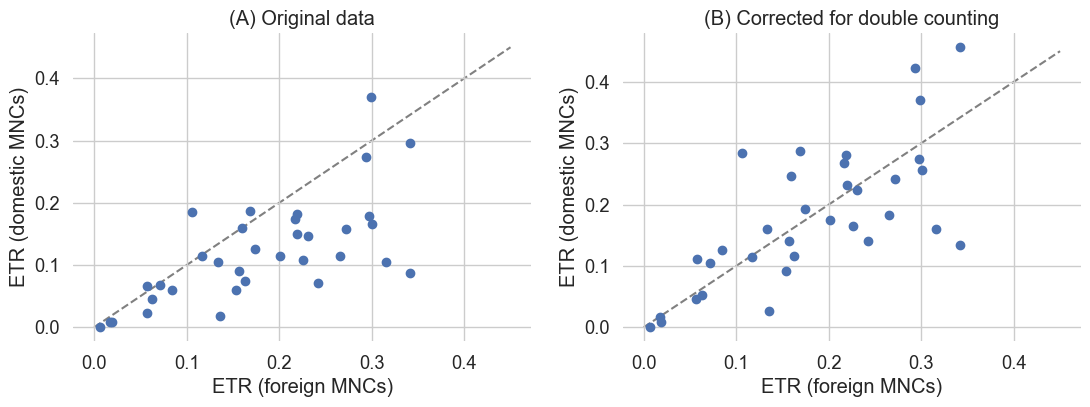

In [109]:
df_etrs2 = main_etrs(year=year_cbcr,file=cbcr_file,g="Sub-Groups with positive profits")
d = pd.concat([df_etrs, df_etrs2],axis=1)
d.columns = ["f1","d1","t1","cit","f2","d2","t2"]

def plot_etr_robustness(d,v2):
    plt.plot(d["f1"],d[v2],"o")
    plt.plot([0,0.45],[0,0.45],"--",color="gray",zorder=0)
    plt.xlabel("ETR (foreign MNCs)")
    plt.ylabel("ETR (domestic MNCs)")
    sns.despine(bottom=True,left=True)
    
plt.figure(figsize=(13,4))
plt.subplot(121)
plot_etr_robustness(d,"d2")
plt.title("(A) Original data")

plt.subplot(122)
plot_etr_robustness(d,"d1")
plt.title("(B) Corrected for double counting")

In [110]:
#Fix code for kosovo
df["COU"] = df["COU"].replace({"XKV": "XKX"})
df["JUR"] = df["JUR"].replace({"XKV": "XKX"})

In [111]:
# df_fin.loc[df_fin["iso3_o"]=="USA"].sort_values(by="pi",ascending=False)

## 2. Create other variables to train the model

## 2.1. Financial information

In [112]:
#Financial variables
df_fin = df.loc[df["Grouping"]=="All Sub-Groups",["COU","JUR","Number of Employees","Profit (Loss) before Income Tax","Income Tax Paid (on Cash Basis)","Unrelated Party Revenues","Tangible Assets other than Cash and Cash Equivalents"]]
df_fin.columns = ["iso3_o","iso3_d","emp","pi","txc","revt","t_at"]
df_fin["iso3_d"] = df_fin["iso3_d"].replace("ANT","CUW")


In [113]:
## Countries to include
countries_include = set([_ for _ in df_fin["iso3_d"].unique() if not isinstance(get_iso3(_),float)]) - {"IOT","BVT"}# - {"BVT","GUM","ASM","VIR"} #tiny ocuntry with almost no profits, not in the distance dataset

FJT not matched to any file
OAM not matched to any file
OAS not matched to any file
OTE not matched to any file
OAF not matched to any file
STA not matched to any file
AFRIC not matched to any file
AMER not matched to any file
ASIAT not matched to any file
EUROP not matched to any file
GRPS not matched to any file


/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_9820/1938015452.py:2: DeprecationWarning: This method is going to be deprecated use name_to_iso3 and iso3_to_iso2 instead.
  countries_include = set([_ for _ in df_fin["iso3_d"].unique() if not isinstance(get_iso3(_),float)]) - {"IOT","BVT"}# - {"BVT","GUM","ASM","VIR"} #tiny ocuntry with almost no profits, not in the distance dataset


## 2.2 Basic info and impute missing wages

/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_9820/1409174636.py:15: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  ohter_info[i] = ohter_info.groupby(['iso3'], sort=False)[i].apply(lambda x: x.ffill(limit=3).bfill(limit=3))
/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_9820/1409174636.py:15: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior a

DOM 597.4936564927671 295.0916666666667 0.7054576244656585
HKG 3625.9452337746275 1722.494 0.7443417678704434
IDN 310.02362333908627 145.3125 0.7577619031137478
MEX 809.0118589805337 354.4266666666667 0.8253121153200943
PRT 1797.9876612980486 996.7866666666665 0.5898865807418909
QAT 5590.42327786396 2874.07375 0.6653245564213606
SEN 114.31237718576692 0.32999999999999996 5.847597476299385
                            OLS Regression Results                            
Dep. Variable:     np.log(month_wage)   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.926
Method:                 Least Squares   F-statistic:                     786.1
Date:                Thu, 17 Nov 2022   Prob (F-statistic):           3.67e-71
Time:                        17:27:36   Log-Likelihood:                -32.236
No. Observations:                 127   AIC:                             70.47
Df Residuals:                     124   BIC:           

,iso3,year,IP_payments_wb,IP_receipts_wb,FDI_inflows_WDI_wb,External_debt_stocks_wb,Govt_exp_gdp_wb,Total_reserves_wb,Number_of_new_businesses_registered_wb,Imports_wb,Exports_wb,GDP_pc_wb,GDP_deflator_wb,Govt_exp_educ_gdp_wb,Physicians_per_1000_wb,Nurses_per_1000_wb,Health_exp_gdp_wb,GreenfieldFDI_outward,GreenfieldFDI_inward,resource_revenue,resource_taxes,total_taxes_revenue,cit_revenue,who_gvt_health_expenditure,month_wage,GDP_int,POP_int,FSI2020_Rank,FSI2020_Share,FSI2020_Score,CTHI21_Rank,CTHI21_Share,CTHI21_Score,region,region_tjn,EU28,OECD,G20,UKt,OECD_OCT,Physicians,Nurses,gdppc,resource_revenue_gdp,cit
0,ABW,2016.0,1.237881e+07,709222.656682,4.802879e+07,NaN,NaN,7.439409e+08,NaN,2.233610e+09,2.119206e+09,27785.755446,149.152720,1.807188e+08,NaN,NaN,NaN,5.714286e+04,2.522857e+07,NaN,0.0,6.412902e+08,NaN,NaN,2188.935759,2.966542e+09,1.047770e+05,112.0,0.002251,73.275,56.0,0.002126,70.134565,Americas,Caribbean/American isl.,0.0,0.0,0.0,0.0,1.0,NaN,NaN,28312.907563,NaN,0.25
1,AFG,2016.0,3.949213e+06,53595.839720,7.565272e+07,2.622959e+09,8.088788e+11,6.899700e+09,3030.428571,NaN,NaN,556.681906,103.522239,6.913388e+08,0.277763,0.220556,1.905209e+09,1.050000e+07,9.021429e+07,NaN,NaN,1.535079e+09,2.363759e+08,9.528032e+07,89.595632,1.947716e+10,3.522628e+07,NaN,NaN,NaN,NaN,NaN,NaN,Asia,Asia,0.0,0.0,0.0,0.0,0.0,9784.540092,9784.540092,552.915490,NaN,0.20


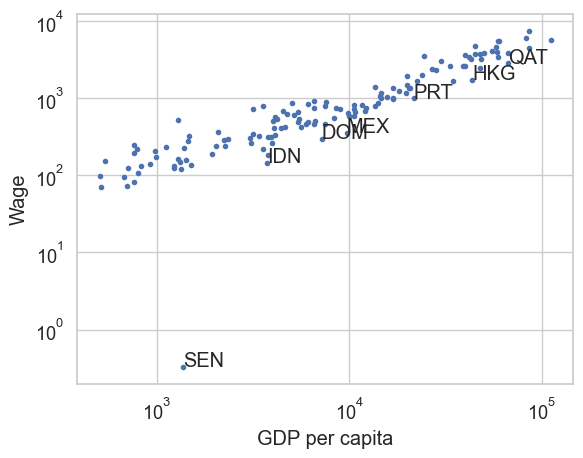

In [114]:

## Read region
region = pd.read_csv(country_level,skiprows=1,sep="\t",usecols=["iso3","region_tjn","region","UKt","OECD","OECD_OCT","EU28","G20",
                                                               "FSI2020_Rank","FSI2020_Share","FSI2020_Score","CTHI21_Rank","CTHI21_Share","CTHI21_Score"])

##Other info
usecols = ["iso3","year","GDP_int","POP_int","Physicians_per_1000_wb","Nurses_per_1000_wb","GreenfieldFDI_inward","GreenfieldFDI_outward",
           "resource_revenue","resource_taxes","total_taxes_revenue","cit_revenue","Health_exp_gdp_wb","Govt_exp_educ_gdp_wb",
          "FDI_inflows_WDI_wb","External_debt_stocks_wb",'IP_payments_wb','IP_receipts_wb','who_gvt_health_expenditure',"month_wage",
           'Total_reserves_wb','Number_of_new_businesses_registered_wb','Imports_wb','Exports_wb','GDP_pc_wb','GDP_deflator_wb','Govt_exp_gdp_wb']

ohter_info = pd.read_csv(country_year_level,skiprows=1,sep="\t",usecols=usecols)

#Fill forward to get old data (in case of missing)
for i in ["GDP_int","POP_int","Physicians_per_1000_wb","Nurses_per_1000_wb"]:
    ohter_info[i] = ohter_info.groupby(['iso3'], sort=False)[i].apply(lambda x: x.ffill(limit=3).bfill(limit=3))

#Keep mean >2010
ohter_info = ohter_info.loc[ohter_info["year"]>last_year_mean].groupby("iso3").mean().reset_index()

#Merge with region
ohter_info = pd.merge(ohter_info,region,how="outer")

#Raw numbers
ohter_info["Physicians"] = ohter_info["Physicians_per_1000_wb"]*ohter_info["POP_int"]/1000
ohter_info["Nurses"] = ohter_info["Physicians_per_1000_wb"]*ohter_info["POP_int"]/1000

#GDP per capita
ohter_info["gdppc"] = ohter_info["GDP_int"]/ohter_info["POP_int"]

#Convert to USD
for i in ['who_gvt_health_expenditure',"resource_revenue","resource_taxes","total_taxes_revenue","cit_revenue","Health_exp_gdp_wb","Govt_exp_educ_gdp_wb","Govt_exp_gdp_wb"]:
    ohter_info[i] = ohter_info[i]*ohter_info["GDP_int"]
    
ohter_info["resource_revenue_gdp"] = ohter_info["resource_revenue"]/ohter_info["GDP_int"]

ohter_info["Govt_exp_educ_gdp_wb"] /= 100
ohter_info["Health_exp_gdp_wb"] /= 100

remove = []
for i,x,y in zip(ohter_info["iso3"],ohter_info["GDP_int"]/ohter_info["POP_int"],ohter_info["month_wage"]):
    if (np.log(x/12/y)>np.log2(1.5)) or (np.log(x/12/y)<-2):
        print(i,x/12,y,np.abs(np.log(x/12/y)))
        plt.annotate(i,(x,y))
        remove.append(i)
plt.plot(ohter_info["GDP_int"]/ohter_info["POP_int"],ohter_info["month_wage"],".")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("GDP per capita")
plt.ylabel("Wage")

#Delete the problematic ones
ohter_info.loc[ohter_info["iso3"].isin(remove),"month_wage"] = np.nan


mod = smf.ols(formula='np.log(month_wage) ~ np.log(GDP_int) + np.log(POP_int)', data=ohter_info)

res = mod.fit()

print(res.summary())

ohter_info["pred_month_wage"] = np.exp(res.predict(ohter_info))
ohter_info.loc[np.isnan(ohter_info["month_wage"]),"month_wage"] = ohter_info.loc[np.isnan(ohter_info["month_wage"]),"pred_month_wage"]

del ohter_info["pred_month_wage"]
#Fix the departing ones
ohter_info.loc[ohter_info["iso3"]=="USA","month_wage"] =  4056 #https://www.bls.gov/news.release/pdf/wkyeng.pdf
ohter_info.loc[ohter_info["iso3"]=="AUS","month_wage"] =  5661 #https://www.abs.gov.au/statistics/labour/earnings-and-work-hours/average-weekly-earnings-australia/latest-release

#ADD CIT
ohter_info["cit"] = ohter_info["iso3"].map(iso3_to_cit)
ohter_info = ohter_info.drop_duplicates()

ohter_info.to_csv(info_expenditures_output, sep="\t", index=None)
 


ohter_info.head(2)

In [115]:
iso3_to_gdp = ohter_info.set_index("iso3")["GDP_int"].dropna().to_dict()
pickle.dump(iso3_to_gdp,open(iso3_to_gdp_output,"wb+"))


In [116]:
a = pd.read_csv(country_year_level,skiprows=1,sep="\t",nrows=1).columns
[_ for _ in a if "govt_ex" in _.lower()]

['Govt_exp_gdp_wb', 'Govt_exp_educ_gdp_wb', 'Govt_exp_educ_govtexp_wb']

In [117]:
#Other info
df_region = ohter_info.drop(columns=["year"])
df_region = df_region.rename(columns={"iso3":"iso3_d"})
df_region = df_region.drop_duplicates(subset=["iso3_d"]).dropna(subset=["iso3_d"])
iso3_to_region = df_region.set_index("iso3_d")["region_tjn"]

In [118]:
iso3_to_wages = ohter_info.set_index("iso3")["month_wage"].dropna().to_dict()
pickle.dump(iso3_to_wages,open(iso3_to_wages_output,"wb+"))


In [119]:
ohter_info.set_index("iso3")["month_wage"]

iso3
ABW    2188.935759
AFG      89.595632
AGO     411.463465
AIA    1730.294149
ALA    3661.086201
          ...     
UMI            NaN
PAL            NaN
ROM            NaN
TMP            NaN
ZAR            NaN
Name: month_wage, Length: 274, dtype: float64

## 2.3 Gravity dataset

In [120]:
def add_eq(df_dist,list_c,eq):
    """copies the data of another country"""
    for c in list_c:
        x = df_dist.loc[df_dist["iso3_o"]==eq]
        x["iso3_o"] = c
        df_dist = pd.concat([df_dist,x])
        x = df_dist.loc[df_dist["iso3_d"]==eq]
        x["iso3_d"] = c
        df_dist = pd.concat([df_dist,x])
    return df_dist



In [123]:
# Read gravity variables
df_dist = pd.read_stata(grav_file)
df_dist = df_dist.loc[df_dist["year"]>last_year_mean].groupby(["iso3_o","iso3_d"]).mean().reset_index()

df_dist["iso3_o"] = df_dist["iso3_o"].str.replace("ROM","ROU")
df_dist["iso3_d"] = df_dist["iso3_d"].str.replace("ROM","ROU")
df_dist["iso3_o"] = df_dist["iso3_o"].str.replace("TLS","TMP")
df_dist["iso3_d"] = df_dist["iso3_d"].str.replace("TLS","TMP")
# df_dist["iso3_o"] = df_dist["iso3_o"].str.replace("ANT","CUW")
# df_dist["iso3_d"] = df_dist["iso3_d"].str.replace("ANT","CUW")
df_dist = df_dist.loc[(df_dist["iso3_o"]!="ANT")&(df_dist["iso3_d"]!="ANT")]

df_dist = add_eq(df_dist,["JEY","IMN","GGY"],"GBR")
# df_dist = add_eq(df_dist,["SRB","MNE"],"ALB")
# df_dist = add_eq(df_dist,["MCO"],"AND")
# df_dist = add_eq(df_dist,["SSD"],"SDN")
# df_dist = add_eq(df_dist,["COD"],"COG")
df_dist = add_eq(df_dist,["TLS"],"COG")


/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_9820/3910450282.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_dist = df_dist.loc[df_dist["year"]>last_year_mean].groupby(["iso3_o","iso3_d"]).mean().reset_index()


In [124]:
df_dist["iso3_d"].value_counts().head(5) #make sure there are no duplicates

ABW    251
PHL    251
NGA    251
NIC    251
NIU    251
Name: iso3_d, dtype: int64

In [127]:
set(df_fin["iso3_d"]) - set(df_dist["iso3_o"])

{'AFRIC',
 'AMER',
 'ASIAT',
 'EUROP',
 'FJT',
 'GRPS',
 'OAF',
 'OAM',
 'OAS',
 'OTE',
 'STA',
 'VIR',
 'XKX'}

In [128]:
for i in set(df_fin["iso3_d"]) - set(df_dist["iso3_o"]):
    try:
        iso3_to_name(i)
    except:
        print(i)

ASIAT
OAF
STA
EUROP
AMER
FJT
OTE
OAM
GRPS
AFRIC
OAS


## 2.4 Variables from Linkedin

In [129]:
# Linkedin variables
df_link = pd.read_csv(link_file,sep="\t",index_col=0,na_values=[""],keep_default_na=False)
df_link["iso3_d"] = df_link["index"].map(get_iso3)
df_link = df_link.drop(columns=["index","country","ln_pi"])
df_link = df_link.drop_duplicates(subset=["iso3_d"])

## 2.5 Bilateral info

In [130]:
df_bil = pd.read_csv(bilateral_level,skiprows=1,sep="\t")
df_bil = df_bil.groupby(["r_iso3","p_iso3"]).mean().reset_index()
df_bil = df_bil.loc[:,["r_iso3","p_iso3", 'Export', 'Import','dClaims','dLiabilities','PortI_inward','PortI_outward', 'FDI_inward', 'FDI_outward']]
for v in ['Export', 'Import','dClaims','dLiabilities','PortI_inward','PortI_outward', 'FDI_inward', 'FDI_outward']:
    df_bil["ln_"+v] = np.log(df_bil[v]+1)
    del df_bil[v]
    
df_bil = df_bil.rename(columns={"r_iso3":"iso3_o", "p_iso3": "iso3_d"})

df_bil

,iso3_o,iso3_d,ln_Export,ln_Import,ln_dClaims,ln_dLiabilities,ln_PortI_inward,ln_PortI_outward,ln_FDI_inward,ln_FDI_outward
0,ABW,AFG,13.558630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,AGO,16.031576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,AIA,NaN,NaN,NaN,NaN,NaN,NaN,16.234725,NaN
3,ABW,ALB,5.680173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,AND,NaN,8.065894,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
50596,ZWE,WSM,9.679281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50597,ZWE,XKX,8.497195,4.615121,NaN,NaN,NaN,NaN,NaN,NaN
50598,ZWE,YEM,12.695013,8.216298,NaN,NaN,NaN,NaN,NaN,NaN
50599,ZWE,ZAF,21.414037,21.765608,18.801398,17.95201,17.530718,NaN,20.997196,19.539148


## 2.5 Combine datasets into a bilateral dataset

In [131]:
iso3_to_etr = df_etrs["ETR_total"].to_dict()

In [132]:
## Dataset to impute (financials and weird stuff) (destination files)
#Keep the non-bilateral columns (note the drop_duplicates)
x = df_dist.loc[:,[_ for _ in df_dist.columns if  (_[-2:]=="_d") and (_ not in ["heg_d","gsp_d_d","gsp_o_d","eu_d","tradeflow_comtrade_d","tradeflow_imf_d"])]].drop_duplicates()
print(x.shape) #should be around 257 countries

df_destination = pd.merge(x,df_region,how="outer")
df_destination = pd.merge(df_destination,df_link.drop(columns=["cit","ln_gdp"]),how="left",on=["iso3_d"],suffixes=["","_d"])
df_destination["n_companies_orb"] = df_destination["iso3_d"].map(expected_companies).fillna(0)

#Add efective tax rate
df_destination["etr_real_d"] = df_destination["iso3_d"].map(iso3_to_etr)
df_destination["ln_etr_real_d"] = np.log(0.001+df_destination["etr_real_d"])
df_destination = df_destination.dropna(subset=["GDP_int"])

remove_cols_dest = df_destination.columns

#Take the logarithm for many variiables
columns = np.array(df_destination.columns)[df_destination.dtypes!=object]
for var in columns:
    if (var == "english") or (var == "etr") or ("ln" in var) or ("comrelig" in var) or ("comleg" in var):
        continue
    if len(df_destination.loc[:,var].unique()) < 5:
        continue
    m = np.min(df_destination.loc[:,var].dropna())
    if m>0:
        m = 0
#     print(var,m,np.mean(df_destination.loc[:,var]-m)/(np.median(df_destination.loc[:,var].dropna()-m)))
    if ("GDP" in var) or (var == "distw") or ((np.mean(df_destination.loc[:,var]-m) > 2.*np.median(df_destination.loc[:,var].dropna()-m))):# or (var in ["Total FSI","cthi"]):
        print(var,m,np.mean(df_destination.loc[:,var]-m)/(np.median(df_destination.loc[:,var].dropna()-m)))
        df_destination["ln_"+var] = np.log(1+df_destination.loc[:,var]-m)
        del df_destination[var]
        
        
        

(251, 17)
pop_d 0 5.046652433137747
gdp_d 0 14.287887507320935
gdpcap_d 0 2.5412507
gdp_ppp_d 0 8.464649866486736
pop_pwt_d 0 4.548121
gdp_ppp_pwt_d 0 8.600988
entry_cost_d 0.0 2.3336668445393096
IP_payments_wb 0.0 98.26314116739307
IP_receipts_wb -1450000.0 624.0354841827162
FDI_inflows_WDI_wb -12971077988.420889 2.419849896368909
External_debt_stocks_wb 0 6.811681867993125
Govt_exp_gdp_wb 0 29.338583221836945
Total_reserves_wb 0 13.459445278260045
Number_of_new_businesses_registered_wb 0 3.9759588927181113
Imports_wb 0 17.207067549775786
Exports_wb 0 18.7348871965814
GDP_pc_wb 0 2.5886154102873236
GDP_deflator_wb 0 1.8814015394885926
Govt_exp_educ_gdp_wb 0 34.409121663226486
Health_exp_gdp_wb 0 43.80049012190971
GreenfieldFDI_outward 0.0 72.09497999398363
GreenfieldFDI_inward 0.0 10.209921721457098
resource_revenue 0.0 243.57135065144666
resource_taxes 0.0 inf
total_taxes_revenue 0 21.294813075159418
cit_revenue 0.0 15.68641306037571
who_gvt_health_expenditure 0 35.388667445511665
mo

/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_9820/698409254.py:29: RuntimeWarning: divide by zero encountered in double_scalars
  print(var,m,np.mean(df_destination.loc[:,var]-m)/(np.median(df_destination.loc[:,var].dropna()-m)))
/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_9820/698409254.py:29: RuntimeWarning: divide by zero encountered in double_scalars
  print(var,m,np.mean(df_destination.loc[:,var]-m)/(np.median(df_destination.loc[:,var].dropna()-m)))


In [133]:
df_destination = df_destination.loc[(df_destination["iso3_d"]!="WLD")]

columns = np.array(df_destination.columns)[df_destination.dtypes!=object]
# df_destination = impute(df_destination,columns)


df_destination.columns = [_+"_d" if _[-2:]!="_d" else _ for _ in df_destination.columns]

for var in ["ln_resource_revenue_d", "ln_resource_revenue_gdp_d","ln_total_taxes_revenue_d","ln_cit_revenue_d"]:
    df_destination.loc[df_destination[var]<0,var] = 0


df_destination2 = df_destination.copy()
df_destination2.columns = [_[:-1]+"o" if _[-2:]=="_d" else _ for _ in df_destination.columns]

# #Add dummies
# df_destination = pd.concat([df_destination,pd.get_dummies(df_destination["iso3_d"])],axis=1)

print(df_destination.shape)

countries_include - set(df_destination["iso3_d"])

(239, 89)


set()

In [134]:
#Create a full dataset
pairs = list(product(countries_include,repeat=2))
pairs = pd.DataFrame(pairs,columns=["iso3_o","iso3_d"])

pairs = pd.merge(pairs, df_fin,how="left",validate="1:1")
pairs = pd.merge(pairs,df_destination,how="left",on=["iso3_d"],validate="m:1")
pairs = pd.merge(pairs,df_destination2,how="left",suffixes=["_d","_o"],on=["iso3_o"],validate="m:1")

df_dist2 = df_dist.loc[:,["iso3_o","iso3_d"]+[_ for _ in df_dist if (_ not in df_destination.columns) and (_ not in df_destination2.columns) and ("ln"+_ not in df_destination.columns) and ("ln"+_ not in df_destination2.columns) and (_ not in remove_cols_dest)]]
pairs = pd.merge(pairs,df_dist2,how="left",on=["iso3_o","iso3_d"],validate="1:1")
pairs = pd.merge(pairs,df_bil,how="left",on=["iso3_o","iso3_d"],validate="1:1")

# pairs = pairs.drop(columns=["conflict","indepdate","sever","sib_conflict","pta_bb","fta_bb","fta_hmr"])
pairs = pairs.drop(columns=["sib_conflict"])


print(pairs.dropna(subset=["pi"]).shape)

(2019, 231)


In [135]:
pairs["ln_etr_real_o"] = np.log(0.01+pairs["etr_real_o"])
pairs["ln_etr_real_d"] = np.log(0.01+pairs["etr_real_d"])

In [136]:
pairs["ln_cit_o"] = np.log(0.01+pairs["cit_o"])
pairs["ln_cit_d"] = np.log(0.01+pairs["cit_d"])

In [137]:
set(["gdp_o","pop_o","gdpcap_o","entry_cost_o","area_o","eu_o","eu_d","year","region_d","region_o"])-set(pairs.columns)

{'area_o'}

In [138]:
pairs = pairs.drop(columns=["gdp_o","pop_o","gdpcap_o","entry_cost_o","eu_o","eu_d","year","region_d","region_o"])

In [139]:
for i in pairs.columns:
    if len(pairs)-pairs[i].count() > 0 :
        print(i,len(pairs)-pairs[i].count())

emp 43812
pi 43777
txc 43776
revt 43777
t_at 43777
iso3num_d 428
country_exists_d 428
gmt_offset_2020_d 428
gdpcap_ppp_d 4922
gatt_d 428
wto_d 428
entry_proc_d 5778
entry_time_d 5778
entry_tp_d 5778
Physicians_per_1000_wb_d 6420
Nurses_per_1000_wb_d 6206
FSI2020_Rank_d 18404
FSI2020_Share_d 18404
FSI2020_Score_d 18404
CTHI21_Rank_d 31244
CTHI21_Score_d 31244
OECD_OCT_d 214
cit_d 4708
ratings_d 642
english_d 642
Total FSI_d 642
ln_accountant_d 642
ln_all_tax_d 642
ln_banker_d 642
ln_ceo_d 642
ln_cfo_d 642
ln_coo_d 642
ln_cxo_d 642
ln_engineer_d 642
ln_other_corporate_d 642
ln_physician_d 642
ln_tax_compliance_audit_d 642
ln_transfer_pricing_d 642
ln_wealth_d 642
ln_audience_d 642
ln_consumption_d 642
ln_gfcf_d 642
ln_population_d 642
ln_uhnwi_d 642
ln_BIS_d 642
ln_finance_d 642
governance_d 642
tax_complex_d 642
cthi_d 642
etr_real_d 3852
ln_etr_real_d 3852
ln_pop_d 1284
ln_gdp_d 2568
ln_gdpcap_d 2568
ln_gdp_ppp_d 4922
ln_pop_pwt_d 7062
ln_gdp_ppp_pwt_d 7062
ln_entry_cost_d 5778
ln_IP_p

In [140]:
# #fill missing (very few values coming from the distancefile only)
# columns = np.array(pairs.columns)[pairs.dtypes!=object]
# columns = [_ for _ in columns if _ not in df_fin.columns]

# # pairs = impute(pairs,columns)

In [141]:
for var in ["emp","revt","pi","t_at","distw"]:
    pairs["ln_"+var] = np.log(1+pairs.loc[:,var]-m)
    del pairs[var]

/Users/danielcoll/opt/miniconda3/envs/sotj_profit_shifting_estimates/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/danielcoll/opt/miniconda3/envs/sotj_profit_shifting_estimates/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/danielcoll/opt/miniconda3/envs/sotj_profit_shifting_estimates/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [142]:
pairs.to_csv(df_pairs_output,sep="\t",index=None)
df_fin.to_csv(df_fin_output,sep="\t",index=None)

In [143]:
df_fin.head()

,iso3_o,iso3_d,emp,pi,txc,revt,t_at
0,ARG,ARG,143735.0,2.881636e+09,1.216465e+09,4.349976e+10,3.484462e+10
1,ARG,BOL,124.0,2.017711e+06,1.835630e+05,3.967885e+07,2.582452e+07
2,ARG,BRA,4378.0,5.763465e+07,2.949452e+06,4.928930e+08,3.993409e+08
3,ARG,CHL,1799.0,1.097211e+07,1.299770e+06,3.588858e+08,2.288063e+08
4,ARG,COL,13.0,3.437554e+06,-1.093620e+05,1.303132e+07,5.763564e+06


In [144]:
pairs.head()

,iso3_o,iso3_d,txc,iso3num_d,country_exists_d,gmt_offset_2020_d,gdpcap_ppp_d,gatt_d,wto_d,entry_proc_d,entry_time_d,entry_tp_d,Physicians_per_1000_wb_d,Nurses_per_1000_wb_d,FSI2020_Rank_d,FSI2020_Share_d,FSI2020_Score_d,CTHI21_Rank_d,CTHI21_Score_d,region_tjn_d,EU28_d,OECD_d,G20_d,UKt_d,OECD_OCT_d,cit_d,ratings_d,english_d,Total FSI_d,ln_accountant_d,ln_all_tax_d,ln_banker_d,ln_ceo_d,ln_cfo_d,ln_coo_d,ln_cxo_d,ln_engineer_d,ln_other_corporate_d,ln_physician_d,ln_tax_compliance_audit_d,ln_transfer_pricing_d,ln_wealth_d,ln_audience_d,ln_consumption_d,ln_gfcf_d,ln_population_d,ln_uhnwi_d,ln_BIS_d,ln_finance_d,governance_d,...,ln_Nurses_o,ln_resource_revenue_gdp_o,ln_n_companies_orb_o,contig,dist,distcap,distwces,dist_source,comlang_off,comlang_ethno,comcol,comrelig,col45,comleg_pretrans,comleg_posttrans,transition_legalchange,heg_o,heg_d,col_dep_ever,col_dep,col_dep_end_year,col_dep_end_conflict,sibling_ever,sibling,sever_year,gdp_ppp_o,pop_pwt_o,gdp_ppp_pwt_o,rta,tradeflow_comtrade_o,tradeflow_comtrade_d,tradeflow_baci,manuf_tradeflow_baci,tradeflow_imf_o,tradeflow_imf_d,ln_Export,ln_Import,ln_dClaims,ln_dLiabilities,ln_PortI_inward,ln_PortI_outward,ln_FDI_inward,ln_FDI_outward,ln_cit_o,ln_cit_d,ln_emp,ln_revt,ln_pi,ln_t_at,ln_distw
0,BHS,BHS,NaN,44.0,1.0,-5.0,28.707875,0.0,0.0,7.250,21.8750,29.125000,2.107233,3.957533,22.0,0.011961,75.375,12.0,100.000000,Caribbean/American isl.,0.0,0.0,0.0,0.0,0.0,0.00,52.000000,1.000000e+00,84.500000,6.758095,4.110874,5.888878,7.779467,5.017280,4.948760,5.398163,6.918695,2.397895,5.771441,3.433987,0.000000e+00,3.433987,11.760574,22.608905,21.954603,12.842743,0.935973,10.912941,7.955425,1.809529,...,6.681997,NaN,0.693147,0.0,44.407001,44.407001,50.671,1.0,0.0,0.0,0.0,0.287809,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,1.101676e+07,384.146484,11201432.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.60517,-4.605170,NaN,NaN,NaN,NaN,4.708764
1,BHS,BRA,NaN,76.0,1.0,-3.0,15.384000,1.0,1.0,11.500,71.7375,83.237503,2.003911,9.139367,73.0,0.004617,51.675,64.0,29.280815,Latin America,0.0,0.0,1.0,0.0,0.0,0.34,42.000000,6.106227e-16,49.000000,11.846973,10.190207,7.732369,11.605423,9.516427,8.396381,10.256290,12.846692,7.979681,11.692418,11.136208,4.110874e+00,6.846943,17.398977,28.013752,26.734627,19.144068,5.155678,12.686608,13.336750,-0.274247,...,6.681997,NaN,0.693147,0.0,6343.315918,5556.083984,5905.033,1.0,0.0,0.0,0.0,0.242770,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,1.101676e+07,384.146484,11201432.0,0.0,3627.188,2300.516625,3743.337571,2863.184286,2333.025146,2412.091797,14.869110,18.174729,22.488033,22.350006,21.326915,22.601451,23.920791,21.490208,-4.60517,-1.049822,NaN,NaN,NaN,NaN,8.701988
2,BHS,NAM,NaN,516.0,1.0,2.0,10.035875,1.0,1.0,10.000,61.5000,71.500000,0.485356,2.030867,NaN,NaN,NaN,NaN,NaN,Africa,0.0,0.0,0.0,0.0,0.0,0.32,50.000000,1.000000e+00,70.494814,7.808323,5.398163,5.739793,7.544861,4.795791,5.198497,5.638355,7.908755,3.713572,6.042633,3.044522,-2.220446e-16,3.713572,12.245779,23.153755,22.176469,14.673938,0.615648,5.872118,8.674368,0.779564,...,6.681997,NaN,0.693147,0.0,11479.441406,11479.441406,11473.444,1.0,1.0,1.0,0.0,0.351729,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,1.101676e+07,384.146484,11201432.0,0.0,NaN,150980.283286,NaN,NaN,124699.648438,132181.640625,18.477890,16.032749,NaN,NaN,NaN,NaN,NaN,NaN,-4.60517,-1.108663,NaN,NaN,NaN,NaN,9.348164
3,BHS,HTI,NaN,332.0,1.0,-5.0,2.207875,1.0,1.0,12.000,101.6250,113.625000,0.152433,0.716100,NaN,NaN,NaN,NaN,NaN,Caribbean/American isl.,0.0,0.0,0.0,0.0,0.0,0.30,30.604624,5.551115e-17,66.435775,7.848153,3.713572,4.709530,7.934155,4.510860,4.262680,5.442418,7.948385,2.397895,7.139660,3.044522,0.000000e+00,3.044522,12.144734,23.436442,22.211462,16.198570,0.059319,5.828946,7.804251,-2.882370,...,6.681997,NaN,0.693147,0.0,891.750000,891.750000,890.398,1.0,0.0,0.0,0.0,0.271046,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,1.101676e+07,384.146484,11201432.0,1.0,160.468,NaN,160.444250,119.20600

In [145]:
df_region_notna = df_region.dropna(subset=["iso3_d","region_tjn"])
OAF = AFRIC = set(df_region_notna.loc[df_region_notna["region_tjn"]=="Africa","iso3_d"].dropna())
OAS = ASIAT = set(df_region_notna.loc[df_region_notna["region_tjn"]=="Asia","iso3_d"].dropna())
OTE = EUROP = set(df_region_notna.loc[df_region_notna["region_tjn"]=="Europe","iso3_d"].dropna())
OAM = LAC_sca = set(df_region_notna.loc[df_region_notna["region_tjn"].str.contains("America"),"iso3_d"].dropna())
GRPS = set(df_region_notna["iso3_d"].dropna())
LAC = set(df_region_notna.loc[df_region_notna["region_tjn"]=="Latin America and the Caribbean","iso3_d"].dropna())

d_groups2countries = {"OAF": OAF,
                     "AFRIC": AFRIC,
                     "OAS": OAS,
                     "ASIAT": ASIAT,
                     "OTE": OTE,
                     "EUROP": EUROP,
                     "OAM": OAM,
                     "LAC_sca": LAC_sca,
                     "GRPS": GRPS,
                     "LAC": LAC}

pickle.dump(d_groups2countries,open(d_groups2countries_output,"wb+"))
